In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib

In [2]:
df = pd.read_csv('../data/processed/punjab_food_prices_features.csv', parse_dates=['date'])
results = pd.read_csv('../outputs/model_comparison.csv')

print('Loaded. Shape:', df.shape)

Loaded. Shape: (95, 31)


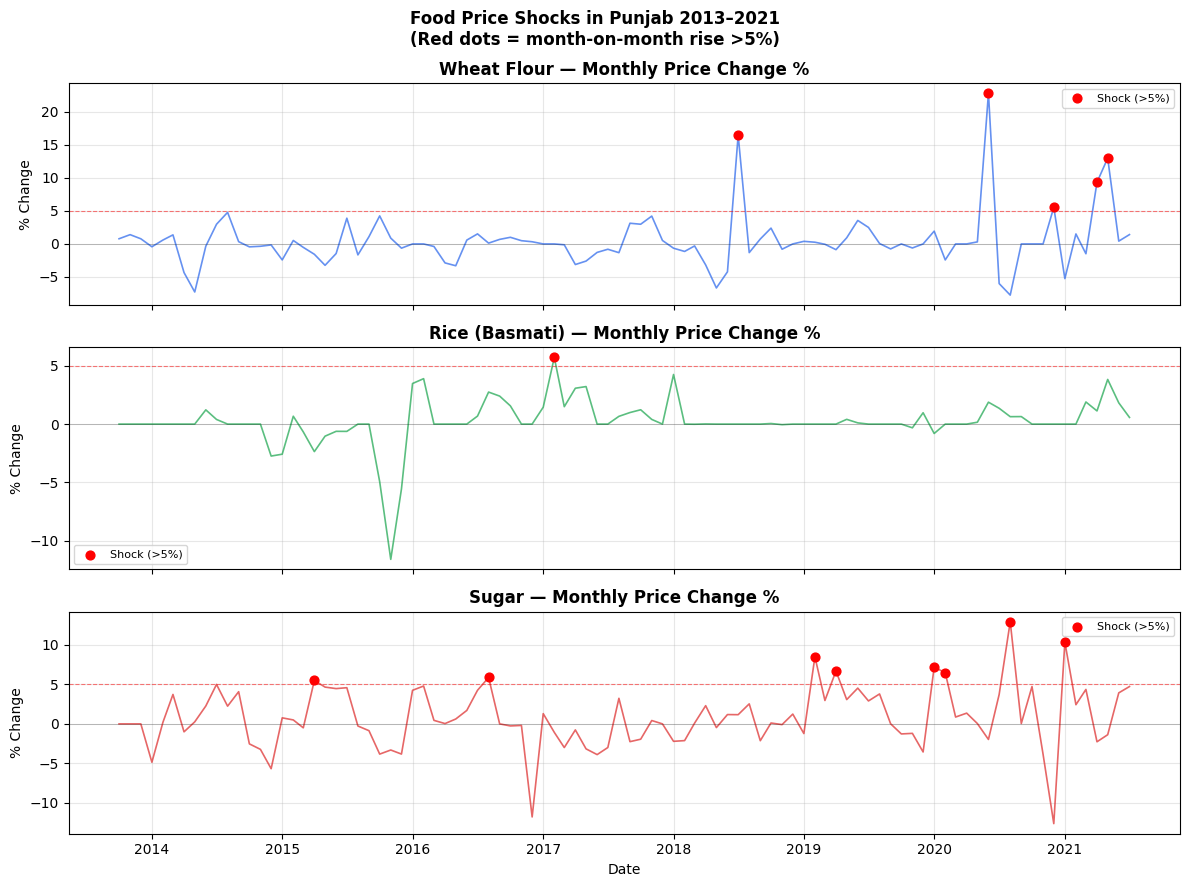

=== PRICE SHOCK SUMMARY ===
Wheat Flour: 5 shocks | Worst: +22.8% in Jun 2020
Rice (Basmati): 1 shocks | Worst: +5.7% in Feb 2017
Sugar: 8 shocks | Worst: +12.9% in Aug 2020


In [3]:
# Calculate month-over-month % change for each commodity
for col in ['wheat_price', 'rice_price', 'sugar_price']:
    df[f'{col}_pct_change'] = df[col].pct_change() * 100

# Define a shock as price rising more than 5% in a single month
shock_threshold = 5

shocks = {}
for col in ['wheat_price', 'rice_price', 'sugar_price']:
    shock_months = df[df[f'{col}_pct_change'] > shock_threshold]
    shocks[col] = shock_months[['date', f'{col}_pct_change']].copy()

# Plot shock frequency
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

colors = {'wheat_price': '#2563EB', 'rice_price': '#16A34A', 'sugar_price': '#DC2626'}
labels = {'wheat_price': 'Wheat Flour', 'rice_price': 'Rice (Basmati)', 'sugar_price': 'Sugar'}

for ax, (col, color) in zip(axes, colors.items()):
    ax.plot(df['date'], df[f'{col}_pct_change'], color=color, linewidth=1.2, alpha=0.7)
    # Highlight shocks in red
    shock_df = df[df[f'{col}_pct_change'] > shock_threshold]
    ax.scatter(shock_df['date'], shock_df[f'{col}_pct_change'],
               color='red', zorder=5, s=40, label=f'Shock (>{shock_threshold}%)')
    ax.axhline(y=shock_threshold, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.set_title(f'{labels[col]} — Monthly Price Change %', fontweight='bold')
    ax.set_ylabel('% Change')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.suptitle('Food Price Shocks in Punjab 2013–2021\n(Red dots = month-on-month rise >5%)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/price_shocks.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print('=== PRICE SHOCK SUMMARY ===')
for col in ['wheat_price', 'rice_price', 'sugar_price']:
    name = labels[col]
    count = len(shocks[col])
    if count > 0:
        worst = shocks[col][f'{col}_pct_change'].max()
        worst_date = shocks[col].loc[shocks[col][f'{col}_pct_change'].idxmax(), 'date']
        print(f'{name}: {count} shocks | Worst: +{worst:.1f}% in {worst_date.strftime("%b %Y")}')

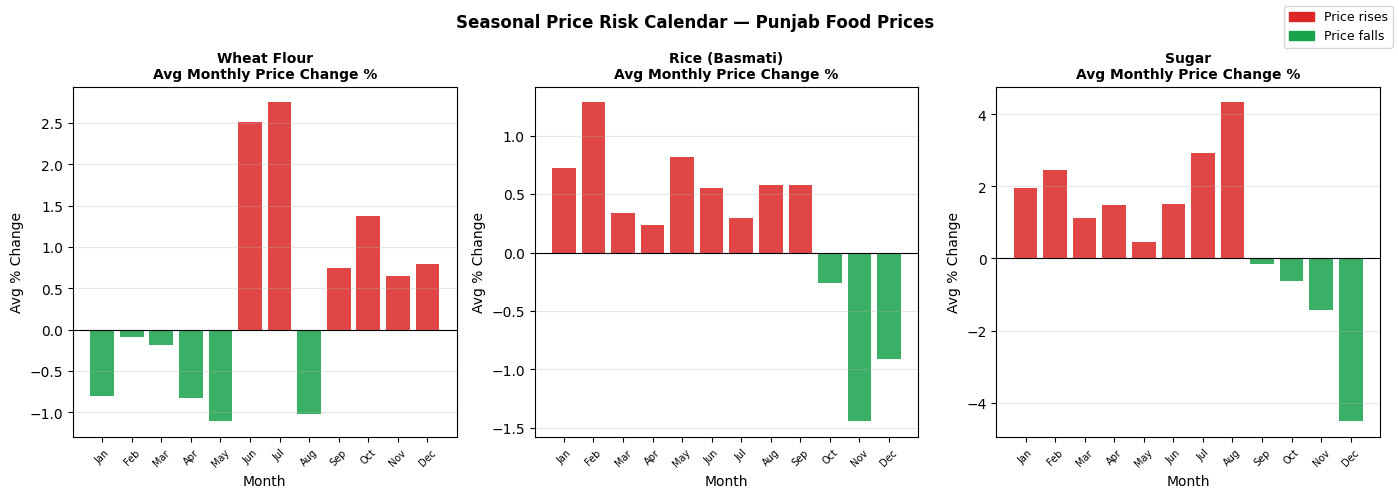

=== HIGHEST RISK MONTHS ===
Wheat Flour: highest avg rise in Jul
Rice (Basmati): highest avg rise in Feb
Sugar: highest avg rise in Aug


In [4]:
# Average price change by month — which months are highest risk?
df['month'] = df['date'].dt.month
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

commodities = [
    ('wheat_price_pct_change', 'Wheat Flour', '#2563EB'),
    ('rice_price_pct_change', 'Rice (Basmati)', '#16A34A'),
    ('sugar_price_pct_change', 'Sugar', '#DC2626')
]

for ax, (col, label, color) in zip(axes, commodities):
    monthly = df.groupby('month')[col].mean()
    bar_colors = ['#DC2626' if v > 0 else '#16A34A' for v in monthly.values]
    ax.bar(monthly.index, monthly.values, color=bar_colors, alpha=0.85)
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_title(f'{label}\nAvg Monthly Price Change %', fontweight='bold', fontsize=10)
    ax.set_xlabel('Month')
    ax.set_ylabel('Avg % Change')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names, fontsize=7, rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

red_patch = mpatches.Patch(color='#DC2626', label='Price rises')
green_patch = mpatches.Patch(color='#16A34A', label='Price falls')
fig.legend(handles=[red_patch, green_patch], loc='upper right', fontsize=9)
plt.suptitle('Seasonal Price Risk Calendar — Punjab Food Prices',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/seasonal_risk_calendar.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== HIGHEST RISK MONTHS ===')
for col, label, _ in commodities:
    monthly = df.groupby('month')[col].mean()
    riskiest = monthly.idxmax()
    print(f'{label}: highest avg rise in {month_names[riskiest-1]}')

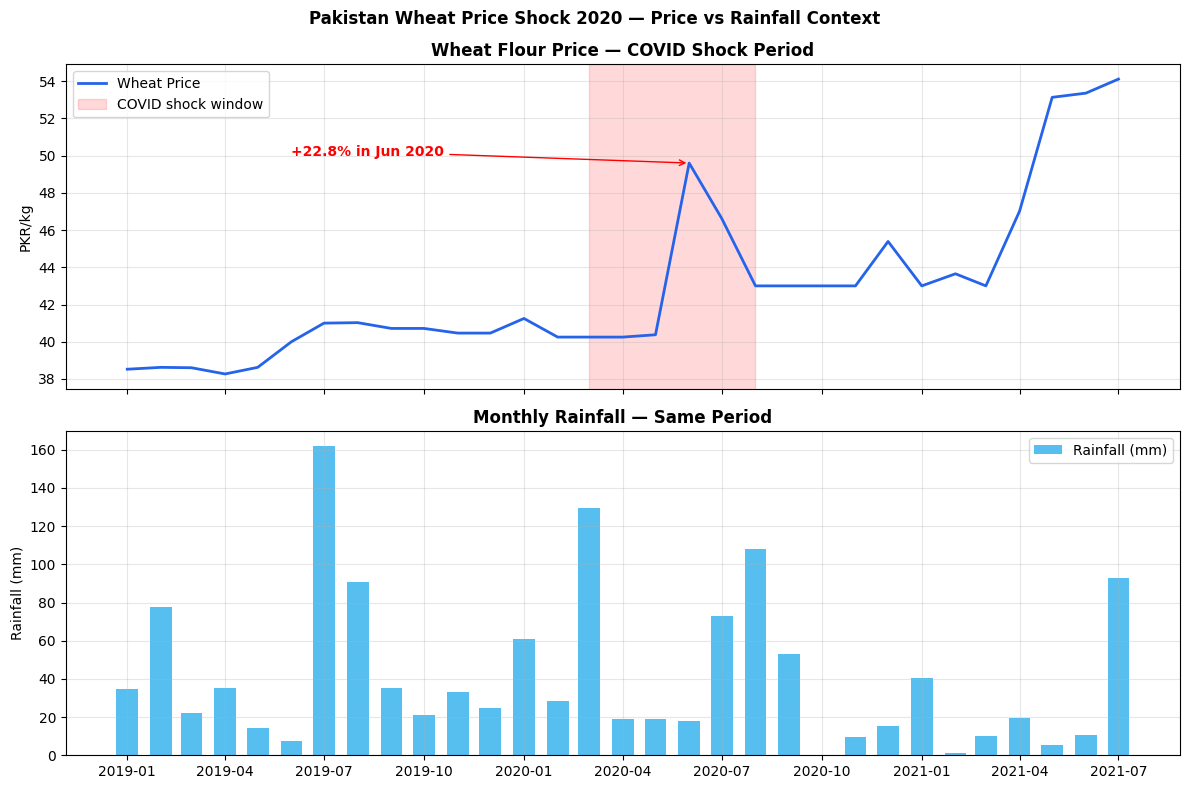

In [5]:
# Isolate the 2019-2021 period — the most dramatic event in your dataset
covid_period = df[(df['date'] >= '2019-01-01') & (df['date'] <= '2021-07-01')].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top plot — wheat price with shock annotation
axes[0].plot(covid_period['date'], covid_period['wheat_price'],
             color='#2563EB', linewidth=2, label='Wheat Price')
axes[0].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-08-01'),
                alpha=0.15, color='red', label='COVID shock window')
axes[0].annotate('+22.8% in Jun 2020',
                 xy=(pd.Timestamp('2020-06-01'), covid_period.loc[covid_period['date']=='2020-06-01', 'wheat_price'].values[0]),
                 xytext=(pd.Timestamp('2019-06-01'), 50),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red', fontweight='bold')
axes[0].set_ylabel('PKR/kg')
axes[0].set_title('Wheat Flour Price — COVID Shock Period', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom plot — rainfall in same period as context
axes[1].bar(covid_period['date'], covid_period['rainfall_mm'],
            color='#0EA5E9', alpha=0.7, width=20, label='Rainfall (mm)')
axes[1].set_ylabel('Rainfall (mm)')
axes[1].set_title('Monthly Rainfall — Same Period', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Pakistan Wheat Price Shock 2020 — Price vs Rainfall Context',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/covid_wheat_shock.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Save final insight summary
insights = {
    'Finding': [
        'Most shock-prone commodity',
        'Most violent single shock',
        'Most stable commodity',
        'Highest risk month - Wheat',
        'Highest risk month - Rice',
        'Highest risk month - Sugar',
        'COVID wheat shock rainfall context',
        'Best model - Wheat',
        'Best model - Rice',
        'Best model - Sugar'
    ],
    'Detail': [
        'Sugar — 8 price shocks above 5% threshold (2013-2021)',
        'Wheat — +22.8% in June 2020 (COVID + drought compounded)',
        'Rice — only 1 shock in 8 years',
        'July — post-harvest stock depletion',
        'February — seasonal supply tightening',
        'August — post-crushing season demand peak',
        'Rainfall below 20mm during worst wheat spike — drought compounded COVID shock',
        'Random Forest — MAE 2.08 PKR/kg',
        'Prophet — MAE 4.39 PKR/kg',
        'Prophet — MAE 3.23 PKR/kg'
    ]
}

insights_df = pd.DataFrame(insights)
insights_df.to_csv('../outputs/project_insights.csv', index=False)
print('Phase 4 complete. Insights saved.')
print(insights_df.to_string(index=False))

Phase 4 complete. Insights saved.
                           Finding                                                                        Detail
        Most shock-prone commodity                         Sugar — 8 price shocks above 5% threshold (2013-2021)
         Most violent single shock                      Wheat — +22.8% in June 2020 (COVID + drought compounded)
             Most stable commodity                                                Rice — only 1 shock in 8 years
        Highest risk month - Wheat                                           July — post-harvest stock depletion
         Highest risk month - Rice                                         February — seasonal supply tightening
        Highest risk month - Sugar                                     August — post-crushing season demand peak
COVID wheat shock rainfall context Rainfall below 20mm during worst wheat spike — drought compounded COVID shock
                Best model - Wheat                            